# DScribe Test

This notebook is a small test of the different functionalities provided by the DScribe package. The goal is then to understand how to integrate it into the existing codebase and use it as a featurizer for the machine learning model.

In [112]:
from ase.io import read 
from ase.build import molecule
from ase import Atoms
import numpy as np
from ase.visualize import view

def random_translate_h2o_dimer(water_dimer, max_translation=0.5):
    """Randomly translates the second water molecule in the dimer by up to max_translation Angstroms in each direction."""
    # Separate the two water molecules
    water1 = water_dimer[:3]  # First 3 atoms belong to the first water molecule
    water2 = water_dimer[3:]  # Last 3 atoms belong to the second water molecule
    
    # Generate random translation vector
    translation_vector = np.random.uniform(-max_translation, max_translation, size=3)
    
    # Apply translation to the second water molecule
    water2.set_positions(water2.get_positions() + translation_vector)
    
    # Combine the two water molecules back into a single Atoms object
    translated_dimer = Atoms(water1 + water2)
    
    return translated_dimer

water_dimer = molecule("H2O2")

# generate 1000 random translations of the water dimer
translated_dimers = [random_translate_h2o_dimer(water_dimer) for _ in range(1000)]

all_species = set()
for dimer in translated_dimers:
    all_species.update(dimer.get_chemical_symbols())
print("Unique chemical species in the dataset:", all_species)

Unique chemical species in the dataset: {'O', 'H'}


We now test with the different descriptors how good we can distinguish between different local minima of the water dimer. The experiment here is as follow we load in 4 different local minima of the water dimer, then to each minima apply really small random pertubations to generate a small cluster of 10 structures around each minima. Then we featurize all the structures with the different descriptors and see how well we can distinguish between the different minima in feature space.

In [113]:
def small_random_perturbation(water_dimer, max_translation=0.5):
    """Applies a small random translation to the second water molecule in the dimer."""
    return random_translate_h2o_dimer(water_dimer, max_translation)

In [114]:
h2o_min1_file = "/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_globalmin.xyz"
h2o_min2_file = "/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_local1.xyz"
h2o_min3_file = "/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2local2.xyz"
h2o_min4_file = "/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_local3.xyz"

h2o_min1 = read(h2o_min1_file)
h2o_min2 = read(h2o_min2_file)
h2o_min3 = read(h2o_min3_file)
h2o_min4 = read(h2o_min4_file)
# for each structure generate 10 pertubations
test_molecules = []
labels_list = [] # Generate a true labels list to which we can compare the clustering results to
for i, minima in enumerate([h2o_min1, h2o_min2, h2o_min3, h2o_min4]):
    for _ in range(100):
        perturbed_structure = small_random_perturbation(minima)
        test_molecules.append(perturbed_structure)
        labels_list.append(i) # Append the label corresponding to the minima

species = set()
for mol in test_molecules:
    species.update(mol.get_chemical_symbols())
print("Unique chemical species in the test set:", species)


Unique chemical species in the test set: {'O', 'H'}


In [115]:
from dscribe.descriptors import SOAP, ACSF, MBTR

soap = SOAP(
    species = species,
    r_cut = 5.0,
    n_max = 8,
    l_max = 8,
    sigma = 0.5,
    rbf = "gto",
    periodic=False
)
soap_features = soap.create(test_molecules, n_jobs=-1)
print("SOAP feature matrix shape:", soap_features.shape)

mtbr = MBTR(
    geometry={"function": "inverse_distance"},
    grid={"min": 0.1, "max": 4, "sigma": 0.1, "n": 100},
    weighting={"function": "exp", "r_cut": 10, "threshold": 1e-3},
    species=species,
    periodic=False
)
mbtr_features = mtbr.create(test_molecules, n_jobs=-1)
print("MBTR feature matrix shape:", mbtr_features.shape)

SOAP feature matrix shape: (400, 6, 1224)
MBTR feature matrix shape: (400, 300)


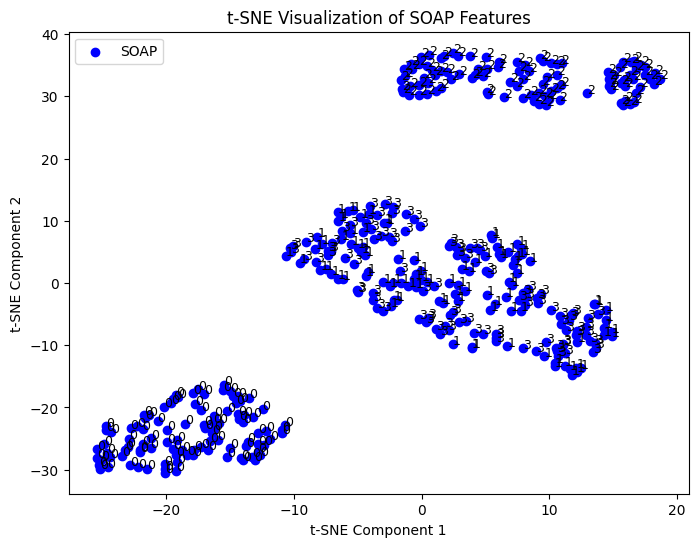

In [116]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# if feature dim = 3 take average over features to get a single value per molecule for visualization
if soap_features.shape[1] > 3:
    soap_features_vis = np.mean(soap_features, axis=1)
else:
    soap_features_vis = soap_features
# Standardize features before t-SNE
scaler = StandardScaler()
soap_features_scaled = scaler.fit_transform(soap_features_vis)
tsne = TSNE(n_components=2, random_state=42)
soap_tsne = tsne.fit_transform(soap_features_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(soap_tsne[:, 0], soap_tsne[:, 1], c='blue', label='SOAP')
# Add labels to the plot
for i in range(len(test_molecules)):
    plt.text(soap_tsne[i, 0], soap_tsne[i, 1], str(labels_list[i]), fontsize=9)
plt.title('t-SNE Visualization of SOAP Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()

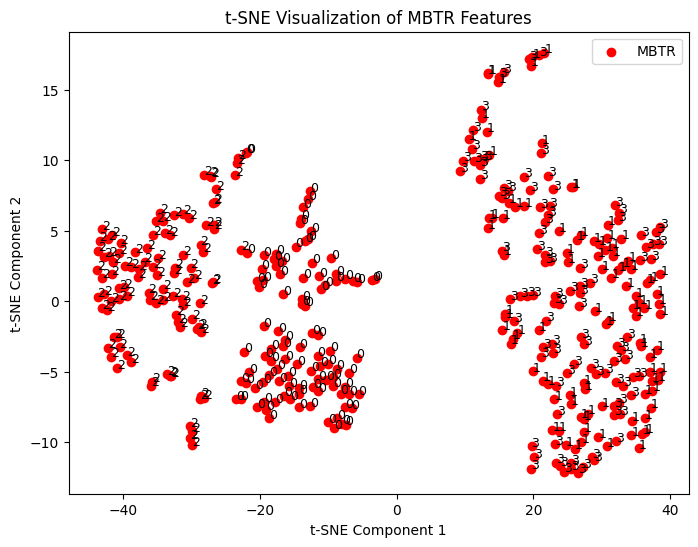

In [117]:
scaler_mbtr = StandardScaler()
mbtr_features_scaled = scaler_mbtr.fit_transform(mbtr_features)
tsne_mbtr = TSNE(n_components=2, random_state=42)
mbtr_tsne = tsne_mbtr.fit_transform(mbtr_features_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(mbtr_tsne[:, 0], mbtr_tsne[:, 1], c='red', label='MBTR')
# Add labels to the plot
for i in range(len(test_molecules)):
    plt.text(mbtr_tsne[i, 0], mbtr_tsne[i, 1], str(labels_list[i]), fontsize=9)
plt.title('t-SNE Visualization of MBTR Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()

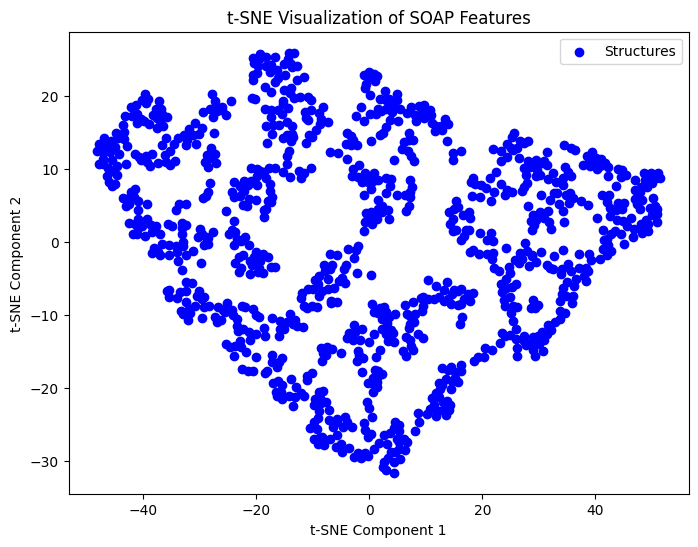

In [118]:
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans 

# Average the SOAP vectors 
if feature_matrix.ndim == 3:
    feature_matrix = feature_matrix.mean(axis=1)
# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(scaled_features)
# Plot the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c='blue', label='Structures')
plt.title('t-SNE Visualization of SOAP Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()